In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/dataset_imoveis.csv')
df.head()

,Preço,Área (m²),Quartos,Banheiros,Garagem,Localização
0,271958,288,4,1,1,Subúrbio
1,821155,86,2,3,1,Zona Sul
2,281932,160,4,1,0,Centro
3,515838,253,1,3,2,Zona Sul
4,409178,278,1,1,0,Subúrbio


In [3]:
df.shape

(1000, 6)

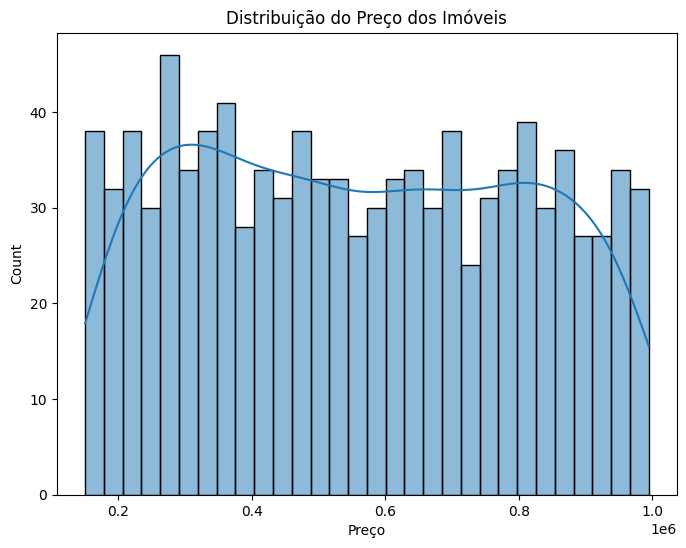

In [5]:
# Análise exploratória
# Distribuição do preço dos imóveis
plt.figure(figsize=(8, 6))
sns.histplot(df['Preço'], bins=30, kde=True)
plt.title('Distribuição do Preço dos Imóveis')
plt.show()

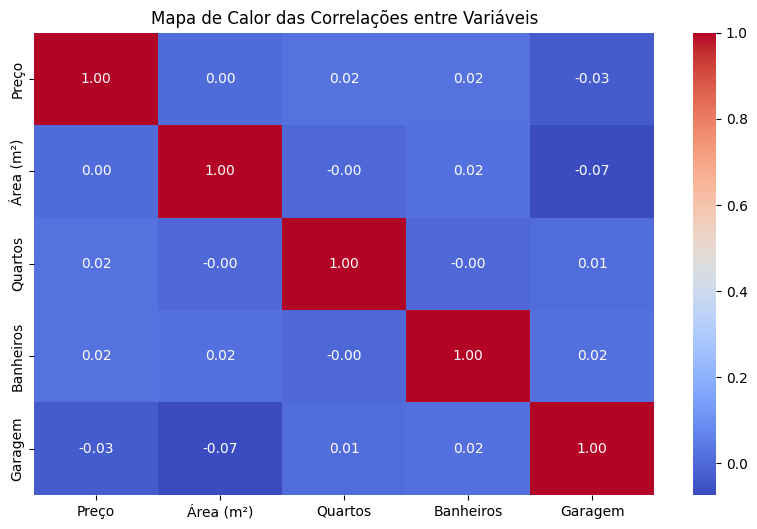

In [7]:
# Mapa de calor das correlações
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor das Correlações entre Variáveis')
plt.show()

In [8]:
# Separar variáveis independentes e dependentes
X = df.drop(columns=['Preço'])
y = df['Preço']

In [9]:
# Identifica dados categóricos como strings
categorical_features = X.select_dtypes(include=['object']).columns

In [10]:
# Dados categóricos são transformados
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for compatibility with LinearRegression
encoded_features = encoder.fit_transform(X[categorical_features])

In [11]:
# Cria um dataframe novo com os dados encoded
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

In [12]:
# Substitui dados categóricos com dados encoded dentro da variável X
X = X.drop(columns=categorical_features)
X = pd.concat([X, encoded_df], axis=1)

In [13]:
# Dividir em dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Create and train models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
def avaliar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.2f}")
    print("-"*30)

# Avaliação dos modelos
avaliar_modelo(lr_model, X_test, y_test)
avaliar_modelo(rf_model, X_test, y_test)


Modelo: LinearRegression
MAE: 224609.89
MSE: 65691423414.84
R²: -0.02
------------------------------
Modelo: RandomForestRegressor
MAE: 237032.90
MSE: 79249739514.91
R²: -0.23
------------------------------
